## **Logistic Regression**
> Different from linear regression, logistic regression is used to predict the probability of a categorical dependent variable.

So let's jump to implementation as I already learned the theory and math behind it. Hehehe :D

In [2]:
# Imports 
import numpy as np

In [3]:
class LOGISTIC_REGRESSION:
    
    def __init__(self,learning_rate=0.01,iterations=1000):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None
        
    def fit(self,X,y):
        n_samples,n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        # Gradient Descent
        for _ in range(self.iterations):
            linear_model = np.dot(X,self.weights) + self.bias
            y_predicted = self._sigmoid(linear_model)
            dw = (1/n_samples)*np.dot(X.T,(y_predicted-y))
            db = (1/n_samples)*np.sum(y_predicted-y)
            self.weights -= self.learning_rate*dw
            self.bias -= self.learning_rate*db
            
    def predict(self,X):
        linear_model = np.dot(X,self.weights) + self.bias
        y_predicted = self._sigmoid(linear_model)
        y_predicted_cls = [1 if i>0.5 else 0 for i in y_predicted]
        return y_predicted_cls
    
    def _sigmoid(self,x):
        return 1/(1+np.exp(-x))

### **Testing the model**

In [4]:
from sklearn.model_selection import train_test_split
from sklearn import datasets
import matplotlib.pyplot as plt

In [5]:
bc = datasets.load_breast_cancer()

In [6]:
x,y = bc.data,bc.target

**Visualizing the data before training the model**

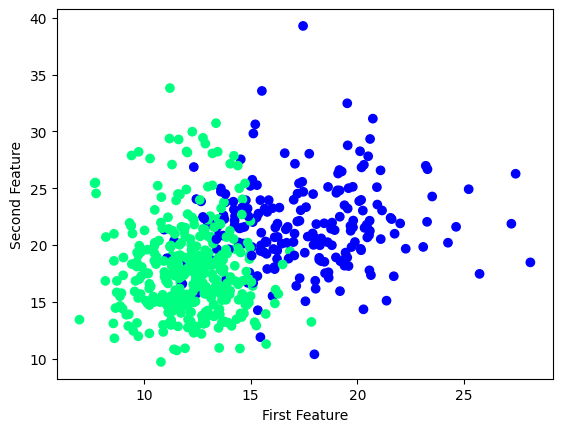

In [7]:
plt.scatter(x[:,0],x[:,1],c=y,cmap='winter')
plt.xlabel('First Feature')
plt.ylabel('Second Feature')
plt.show()

**Training the logistic regression model**

In [8]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=1234)

In [9]:
def accuracy(y_true,y_pred):
    accuracy = np.sum(y_true==y_pred)/len(y_true)
    return accuracy

In [10]:
regressor = LOGISTIC_REGRESSION(learning_rate=0.0001,iterations=1000)
regressor.fit(X_train,y_train)
predictions = regressor.predict(X_test)

In [11]:
print("LR classification accuracy:",accuracy(y_test,predictions))

LR classification accuracy: 0.9298245614035088


**After training the regression model**

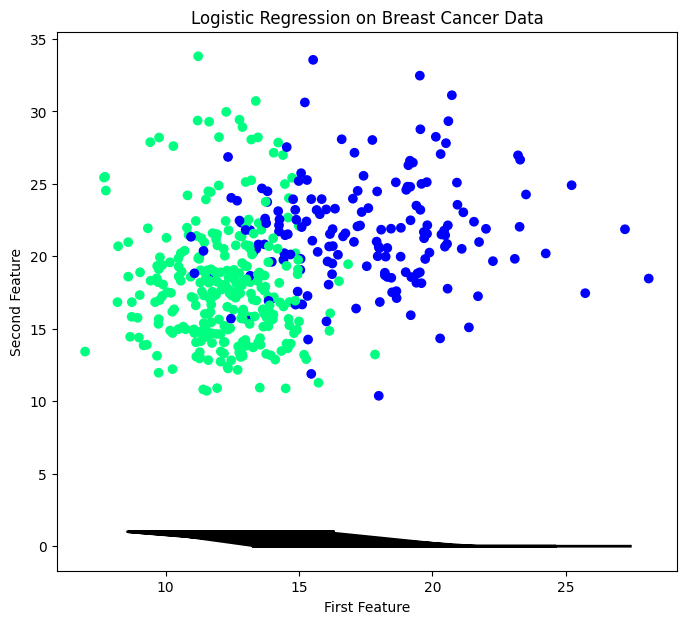

In [15]:
y_pred_line = regressor.predict(X_test)
fig = plt.figure(figsize=(8,7))
plt.scatter(X_train[:,0],X_train[:,1],c=y_train,cmap='winter')
plt.plot(X_test[:,0],y_pred_line,c='black',linewidth=2)
plt.xlabel('First Feature')
plt.ylabel('Second Feature')
plt.title('Logistic Regression on Breast Cancer Data')
plt.show()

> The end of the notebook. Good night :)